In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("02-2023.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,30714010160,2023-02-01 09:05,NaN,00:01:45,NaN,Cameron Dudley
1,30714874806,2023-02-01 09:18,NaN,NaN,NaN,Cameron Dudley
2,30718462301,2023-02-01 09:56,NaN,NaN,NaN,Cameron Dudley
3,30718280986,2023-02-01 09:59,Outbound,00:38:12,NaN,Ray Levesque
4,30717771107,2023-02-01 10:01,NaN,00:00:57,NaN,Vladimir Suparto


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6694 entries, 0 to 6693
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             6694 non-null   int64  
 1   Activity date         6694 non-null   str    
 2   Call direction        256 non-null    str    
 3   Call duration         6014 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  6694 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 552.3 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6694 entries, 0 to 6693
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         6694 non-null   datetime64[us]
 1   Call direction        256 non-null    str           
 2   Call duration         6014 non-null   str           
 3   Activity assigned to  6694 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 343.1 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-02-01 09:05:00,NaN,00:01:45,Cameron Dudley,2023-02-01
1,2023-02-01 09:18:00,NaN,NaN,Cameron Dudley,2023-02-01
2,2023-02-01 09:56:00,NaN,NaN,Cameron Dudley,2023-02-01
3,2023-02-01 09:59:00,Outbound,00:38:12,Ray Levesque,2023-02-01
4,2023-02-01 10:01:00,NaN,00:00:57,Vladimir Suparto,2023-02-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2023-02-01,265
1,2023-02-02,254
2,2023-02-03,297
3,2023-02-04,12
4,2023-02-05,24


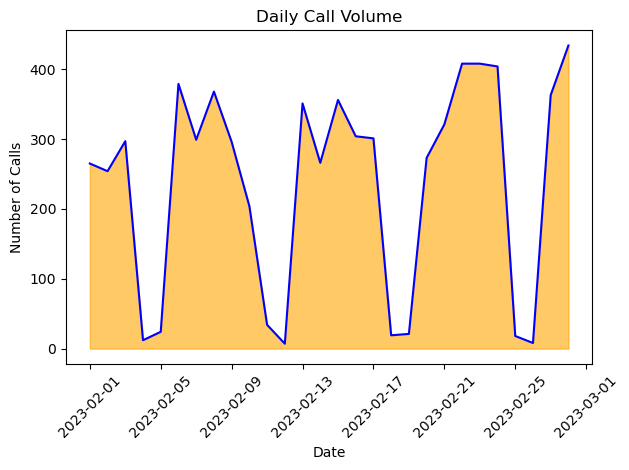

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [29]:
df1['day'] = df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-02-01 09:05:00,NaN,00:01:45,Cameron Dudley,Wednesday
1,2023-02-01 09:18:00,NaN,NaN,Cameron Dudley,Wednesday
2,2023-02-01 09:56:00,NaN,NaN,Cameron Dudley,Wednesday
3,2023-02-01 09:59:00,Outbound,00:38:12,Ray Levesque,Wednesday
4,2023-02-01 10:01:00,NaN,00:00:57,Vladimir Suparto,Wednesday


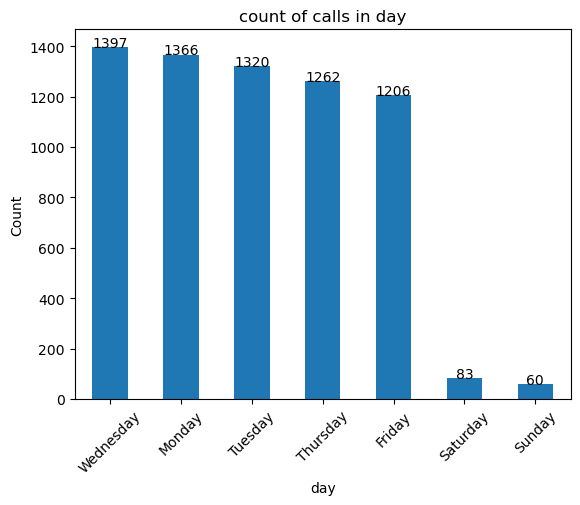

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

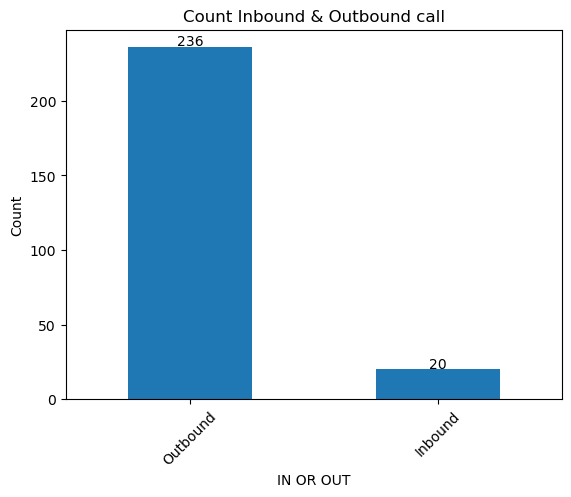

In [37]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [40]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

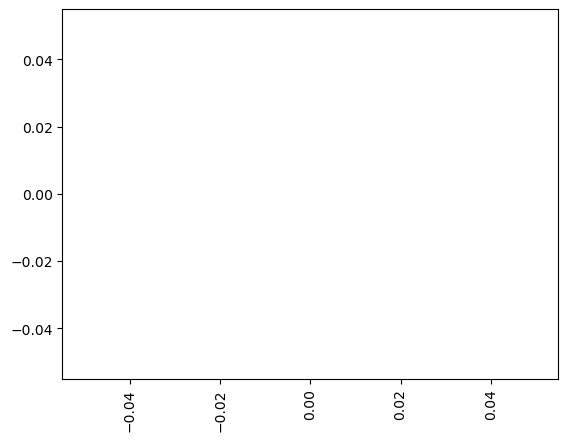

In [42]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration Null but have Call direction

In [45]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
88,2023-02-01 13:19:00,Outbound,NaN,Keith Antonio,Wednesday
171,2023-02-01 15:16:00,Outbound,NaN,Keith Antonio,Wednesday
864,2023-02-06 10:55:00,Outbound,NaN,Keith Antonio,Monday
966,2023-02-06 13:01:00,Outbound,NaN,Keith Antonio,Monday
1087,2023-02-06 14:58:00,Outbound,NaN,Keith Antonio,Monday
...,...,...,...,...,...
6303,2023-02-28 11:49:00,Outbound,NaN,Keith Antonio,Tuesday
6305,2023-02-28 11:53:00,Outbound,NaN,Keith Antonio,Tuesday
6310,2023-02-28 12:00:00,Inbound,NaN,Travis Fleming,Tuesday
6465,2023-02-28 13:17:00,Outbound,NaN,Travis Fleming,Tuesday


In [47]:
df4 = df1.copy()

In [49]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-02-01 09:05:00,NaN,00:01:45,Cameron Dudley,Wednesday
1,2023-02-01 09:18:00,NaN,NaN,Cameron Dudley,Wednesday
2,2023-02-01 09:56:00,NaN,NaN,Cameron Dudley,Wednesday
3,2023-02-01 09:59:00,Outbound,00:38:12,Ray Levesque,Wednesday
4,2023-02-01 10:01:00,NaN,00:00:57,Vladimir Suparto,Wednesday


In [51]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [53]:
(df4['Call duration'] == 0).sum()

0

In [55]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 6694 entries, 0 to 6693
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         6694 non-null   datetime64[us]
 1   Call direction        256 non-null    str           
 2   Call duration         6014 non-null   float64       
 3   Activity assigned to  6694 non-null   str           
 4   day                   6694 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 394.9 KB


In [57]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [59]:
df4 = df4.dropna(subset = ['Call direction'])

In [61]:
(df4['Call duration'] == 0).sum()

61

In [63]:
df4.info()

<class 'pandas.DataFrame'>
Index: 256 entries, 3 to 6658
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         256 non-null    datetime64[us]
 1   Call direction        256 non-null    str           
 2   Call duration         256 non-null    float64       
 3   Activity assigned to  256 non-null    str           
 4   day                   256 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 18.9 KB


# Working Call Assigner

In [66]:
df1['Activity assigned to'].nunique()

18

In [68]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[  'Cameron Dudley',     'Ray Levesque', 'Vladimir Suparto',
     'David Valdez',    'Tommie Walker',   'David Banister',
     'Andy Ramirez',   'Travis Fleming',   'Justin Schmidt',
    'Keith Antonio',      'Adrian Tran',      'Jinky Rance',
     'Dioni Canega',      'Paol Guzman',     'Karen Parker',
 'Kent Encarnacion',        'Terry Kim',     'Stephen Tarr']
Length: 18, dtype: str

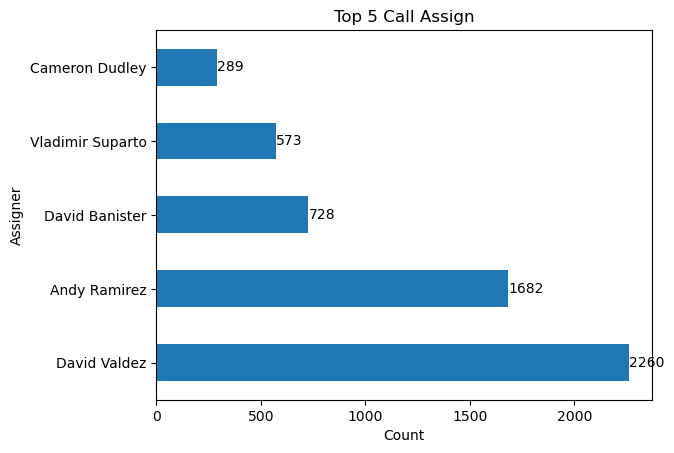

In [70]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [73]:
df4['Call duration'].max()

118.58333333333333

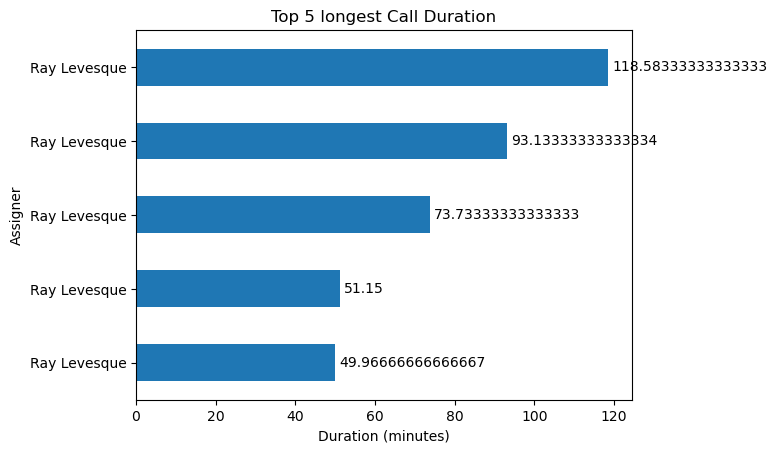

In [75]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [78]:
df3 = df1.copy()

In [80]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [82]:
df3['day'].unique()

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']
Length: 5, dtype: str

In [84]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

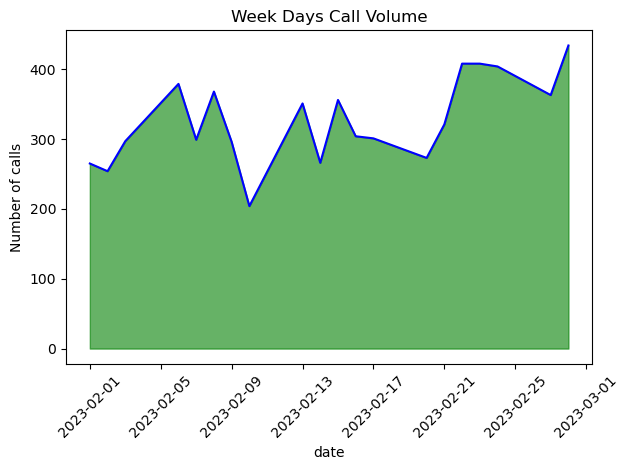

In [86]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [89]:
df5=df4.copy()

In [91]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [93]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
2433,2023-02-12 17:34:00,Outbound,0.000000,Keith Antonio,Sunday
4019,2023-02-18 11:29:00,Outbound,3.616667,Ray Levesque,Saturday
4027,2023-02-18 12:14:00,Outbound,0.583333,Ray Levesque,Saturday
4028,2023-02-18 12:21:00,Outbound,49.966667,Ray Levesque,Saturday
4030,2023-02-18 13:16:00,Outbound,73.733333,Ray Levesque,Saturday


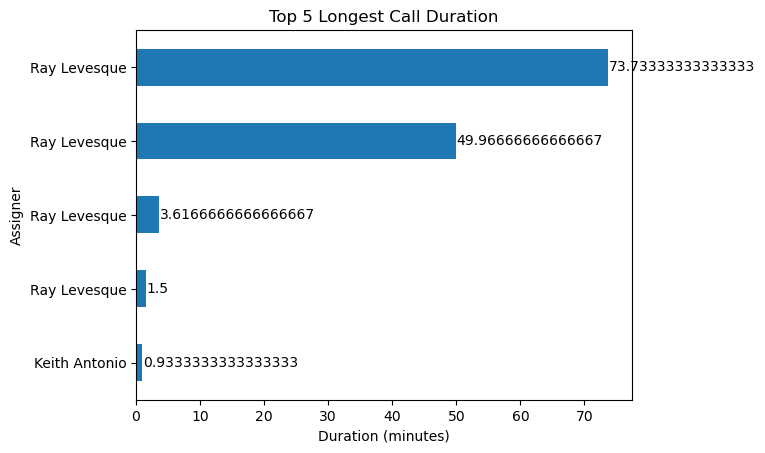

In [95]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend call Assigner

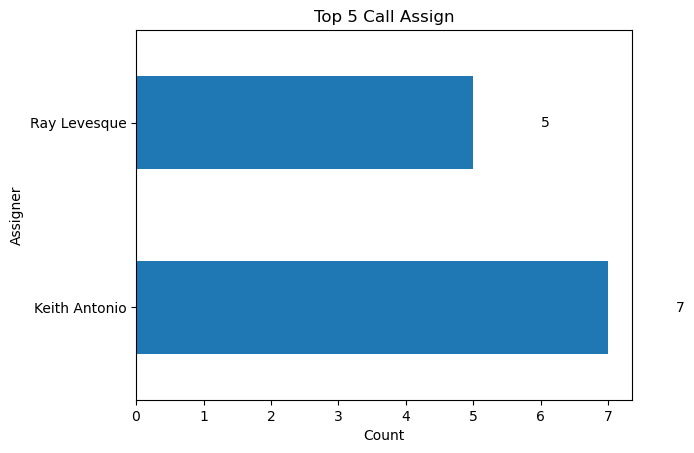

In [98]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [101]:
df4["Call duration"].mean()

6.4796875

In [103]:
df4["Call duration"].median()

0.8666666666666667

# Without Call Assigner Calls

In [106]:
df6 = df3.copy()

In [108]:
df6['month'] = df6['Activity date'].dt.month_name()

In [110]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

IndexError: index 0 is out of bounds for axis 0 with size 0

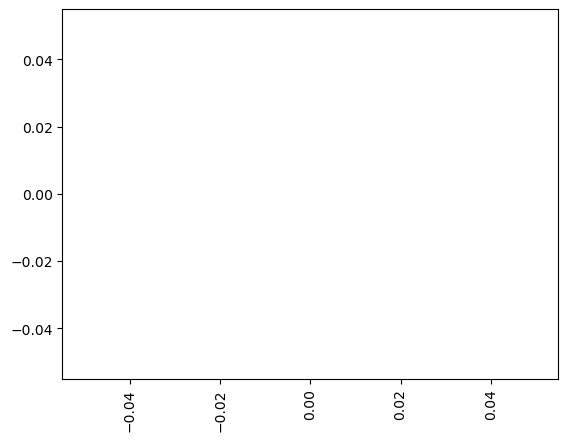

In [112]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call date

In [115]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [117]:
top5 = daily_calls.sort_values(ascending=False).head(5)

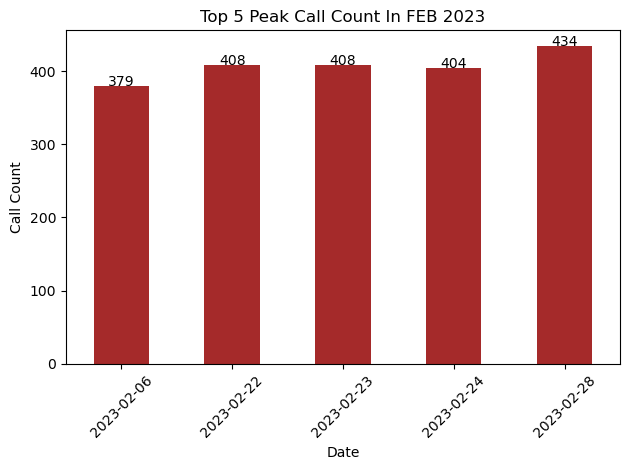

In [121]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In FEB 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()